# Sampling-depth sensitivity: complete final QC versus 100 retained trajectories

This notebook asks how the apparent masked-versus-vanilla distance distributions would look if only 100 retained trajectories had been sampled. The reduced set is drawn deterministically from the same final-QC population used for the complete comparison, ordered by seed and model number. It is therefore a sampling-depth sensitivity analysis, not an independent replicate and not a chronological record of model generation.

CaV1.2 and NaV1.5 use their final 3 Å allOK3 distance subsets. Kv2.1 uses the stricter allOK3 structural-interface/alignment-QC subset. The NaV1.5 comparison is QQQ vanilla versus the original mask v1, matching the primary mutant analysis. Experimental markers retain the same PDB-specific colors and shapes used in the channel notebooks.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

repo_root = Path.cwd() if (Path.cwd() / 'shared').is_dir() else Path.cwd().parent
sys.path.insert(0, str(repo_root)) if str(repo_root) not in sys.path else None

from shared.plotting import CAV12_PALETTE, KV21_PALETTE, NAV15_PALETTE, ACCENT_PALETTE
from shared.sampling_depth_analysis import (
    SUBSETS, load_final_qc_pair, plot_sampling_depth_condition,
    summarize_sampling_depth,
)
from shared.presentation_export import install_notebook_figure_export

install_notebook_figure_export(
    repo_root.parent / 'vgci_mutants_writing' / 'figures' / 'cross_project',
    'SamplingDepth_AllOK3_vs_First100',
)
sns.set_theme(style='whitegrid', context='notebook')


## Final-QC dataset catalog


In [2]:
DATASETS = {
    'CaV1.2 WT': {
        'channel': 'Cav1.2', 'condition': 'WT',
        'colors': {'vanilla': CAV12_PALETTE['WT_VAN'], 'masked': CAV12_PALETTE['WT_HM']},
        'vanilla': repo_root / 'cav12/dataDistances/26-02-10_Cav12_wt_vanillaAF2_distances_all_ok_rmsd_3A.csv',
        'masked': repo_root / 'cav12/dataDistances/26-02-10_Cav12_wt_maskedAF2_distances_all_ok_rmsd_3A.csv',
    },
    'CaV1.2 G402S': {
        'channel': 'Cav1.2', 'condition': 'G402S',
        'colors': {'vanilla': CAV12_PALETTE['G402S_VAN'], 'masked': CAV12_PALETTE['G402S_HM']},
        'vanilla': repo_root / 'cav12/dataDistances/26-02-10_Cav12_g402s_vanillaAF2_distances_all_ok_rmsd_3A.csv',
        'masked': repo_root / 'cav12/dataDistances/26-02-10_Cav12_g402s_maskedAF2_distances_all_ok_rmsd_3A.csv',
    },
    'CaV1.2 G406R': {
        'channel': 'Cav1.2', 'condition': 'G406R',
        'colors': {'vanilla': CAV12_PALETTE['G406R_VAN'], 'masked': CAV12_PALETTE['G406R_HM']},
        'vanilla': repo_root / 'cav12/dataDistances/26-02-10_Cav12_g406r_vanillaAF2_distances_all_ok_rmsd_3A.csv',
        'masked': repo_root / 'cav12/dataDistances/26-02-10_Cav12_g406r_maskedAF2_distances_all_ok_rmsd_3A.csv',
    },
    'Kv2.1 WT': {
        'channel': 'Kv2.1', 'condition': 'WT',
        'colors': {'vanilla': KV21_PALETTE['WT_VAN'], 'masked': KV21_PALETTE['WT_HM']},
        'vanilla': repo_root / 'kv21/dataDistances/26-02-11_Kv2.1_wt_vanillaAF2_distances_all_ok_rmsd_3A_structural_interface_alignment_qc.csv',
        'masked': repo_root / 'kv21/dataDistances/26-02-11_Kv2.1_wt_maskedAF2_distances_all_ok_rmsd_3A_structural_interface_alignment_qc.csv',
    },
    'Kv2.1 L403A': {
        'channel': 'Kv2.1', 'condition': 'L403A',
        'colors': {'vanilla': KV21_PALETTE['L403A_VAN'], 'masked': KV21_PALETTE['L403A_HM']},
        'vanilla': repo_root / 'kv21/dataDistances/26-02-11_Kv2.1_l403a_vanillaAF2_distances_all_ok_rmsd_3A_structural_interface_alignment_qc.csv',
        'masked': repo_root / 'kv21/dataDistances/26-02-11_Kv2.1_l403a_maskedAF2_distances_all_ok_rmsd_3A_structural_interface_alignment_qc.csv',
    },
    'Kv2.1 F412L': {
        'channel': 'Kv2.1', 'condition': 'F412L',
        'colors': {'vanilla': KV21_PALETTE['F412L_VAN'], 'masked': KV21_PALETTE['F412L_HM']},
        'vanilla': repo_root / 'kv21/dataDistances/26-02-11_Kv2.1_f412l_vanillaAF2_distances_all_ok_rmsd_3A_structural_interface_alignment_qc.csv',
        'masked': repo_root / 'kv21/dataDistances/26-02-11_Kv2.1_f412l_maskedAF2_distances_all_ok_rmsd_3A_structural_interface_alignment_qc.csv',
    },
    'NaV1.5 QQQ': {
        'channel': 'Nav1.5', 'condition': 'QQQ | original mask v1',
        'colors': {'vanilla': NAV15_PALETTE['QQQ_VAN'], 'masked': NAV15_PALETTE['QQQ_HM']},
        'vanilla': repo_root / 'nav15/dataDistances/26-07-27_Nav15_qqq_vanilla_AF2_distances_all_ok_rmsd_3A.csv',
        'masked': repo_root / 'nav15/dataDistances/26-07-27_Nav15_qqq_masked_AF2_distances_all_ok_rmsd_3A.csv',
    },
}

path_audit = pd.DataFrame([
    {'Dataset': name, 'Protocol': protocol, 'Path': str(config[protocol]), 'Exists': config[protocol].is_file()}
    for name, config in DATASETS.items() for protocol in ('vanilla', 'masked')
])
display(path_audit)
assert path_audit['Exists'].all(), 'A required final-QC distance table is missing.'


,Dataset,Protocol,Path,Exists
0,CaV1.2 WT,vanilla,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True
1,CaV1.2 WT,masked,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True
2,CaV1.2 G402S,vanilla,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True
3,CaV1.2 G402S,masked,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True
4,CaV1.2 G406R,vanilla,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True
5,CaV1.2 G406R,masked,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True
6,Kv2.1 WT,vanilla,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True
7,Kv2.1 WT,masked,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True
8,Kv2.1 L403A,vanilla,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True
9,Kv2.1 L403A,masked,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True


## Structural coordinates

The comparison uses the same selectivity-filter, voltage-sensor, and intracellular-gate coordinates as the channel notebooks. Experimental overlays are included only where the selected aliases have validated residue correspondences.


In [3]:
REGIONS = {
    'Cav1.2': {
        'selectivity_filter': {'E363-E706':'CA_GLU363_CA-GLU706_CA', 'E363-E1135':'CA_GLU363_CA-GLU1135_CA', 'E363-E1464':'CA_GLU363_CA-GLU1464_CA', 'E706-E1135':'CA_GLU706_CA-GLU1135_CA', 'E706-E1464':'CA_GLU706_CA-GLU1464_CA', 'E1135-E1464':'CA_GLU1135_CA-GLU1464_CA'},
        'vsds': {'F170-R237':'CA_ARG237_CA-PHE170_CA', 'F170-R246':'CA_ARG246_CA-PHE170_CA', 'F567-R620':'CA_ARG620_CA-PHE567_CA', 'F567-K629':'CA_LYS629_CA-PHE567_CA', 'F940-K1015':'CA_LYS1015_CA-PHE940_CA', 'F940-K1031':'CA_ARG1031_CA-PHE940_CA', 'F1278-R1377':'CA_ARG1377_CA-PHE1278_CA', 'F1278-K1386':'CA_LYS1386_CA-PHE1278_CA'},
        'intracellular_gate': {'L401-L749':'CA_LEU401_CA-LEU749_CA', 'L401-V1182':'CA_LEU401_CA-VAL1182_CA', 'L401-I1516':'CA_LEU401_CA-ILE1516_CA', 'L749-V1182':'CA_LEU749_CA-VAL1182_CA', 'L749-I1516':'CA_LEU749_CA-ILE1516_CA', 'V1182-I1516':'CA_VAL1182_CA-ILE1516_CA'},
    },
    'Kv2.1': {
        'selectivity_filter': {'G375 A-B':'CA_CA_A_GLY377_CA-B_GLY377_CA', 'G375 A-C':'CA_CA_A_GLY377_CA-C_GLY377_CA', 'G375 A-D':'CA_CA_A_GLY377_CA-D_GLY377_CA', 'G375 B-C':'CA_CA_B_GLY377_CA-C_GLY377_CA', 'G375 B-D':'CA_CA_B_GLY377_CA-D_GLY377_CA', 'G375 C-D':'CA_CA_C_GLY377_CA-D_GLY377_CA'},
        'vsds': {'F236-R289 A':'CA_CA_A_ARG291_CA-A_PHE238_CA', 'F236-R308 A':'CA_CA_A_ARG310_CA-A_PHE238_CA'},
        'intracellular_gate': {'A402 A-B':'CA_CA_A_ALA404_CA-B_ALA404_CA', 'A402 A-C':'CA_CA_A_ALA404_CA-C_ALA404_CA', 'A402 A-D':'CA_CA_A_ALA404_CA-D_ALA404_CA', 'A402 B-C':'CA_CA_B_ALA404_CA-C_ALA404_CA', 'A402 B-D':'CA_CA_B_ALA404_CA-D_ALA404_CA', 'A402 C-D':'CA_CA_C_ALA404_CA-D_ALA404_CA'},
    },
    'Nav1.5': {
        'selectivity_filter': {'D373-E704':'CA_ASP373_CA-GLU704_CA', 'D373-K1103':'CA_ASP373_CA-LYS1103_CA', 'D373-A1395':'CA_ASP373_CA-ALA1395_CA', 'E704-K1103':'CA_GLU704_CA-LYS1103_CA', 'E704-A1395':'CA_GLU704_CA-ALA1395_CA', 'K1103-A1395':'CA_LYS1103_CA-ALA1395_CA'},
        'vsds': {'F165-R220':'CA_ARG220_CA-PHE165_CA', 'F165-R229':'CA_LYS229_CA-PHE165_CA', 'F560-R612':'CA_ARG612_CA-PHE560_CA', 'F560-K624':'CA_LYS624_CA-PHE560_CA', 'F934-R984':'CA_LYS984_CA-PHE934_CA', 'F934-K1000':'CA_ARG1000_CA-PHE934_CA', 'F1251-R1307':'CA_ARG1307_CA-PHE1251_CA', 'F1251-R1322':'CA_ARG1322_CA-PHE1251_CA'},
        'intracellular_gate': {'M415-A742':'CA_MET415_CA-ALA742_CA', 'M415-I1154':'CA_MET415_CA-ILE1154_CA', 'M415-I1455':'CA_MET415_CA-ILE1455_CA', 'A742-I1154':'CA_ALA742_CA-ILE1154_CA', 'A742-I1455':'CA_ALA742_CA-ILE1455_CA', 'I1154-I1455':'CA_ILE1154_CA-ILE1455_CA'},
    },
}


## Complete versus reduced sampling

Each upper panel uses every model in the final-QC table. Each lower panel uses all retained recycles belonging to the first 100 seed/model trajectories in deterministic order. A difference between panels indicates sensitivity to sampling depth; it does not establish that the first 100 represent a separate conformational population.


Loading CaV1.2 WT


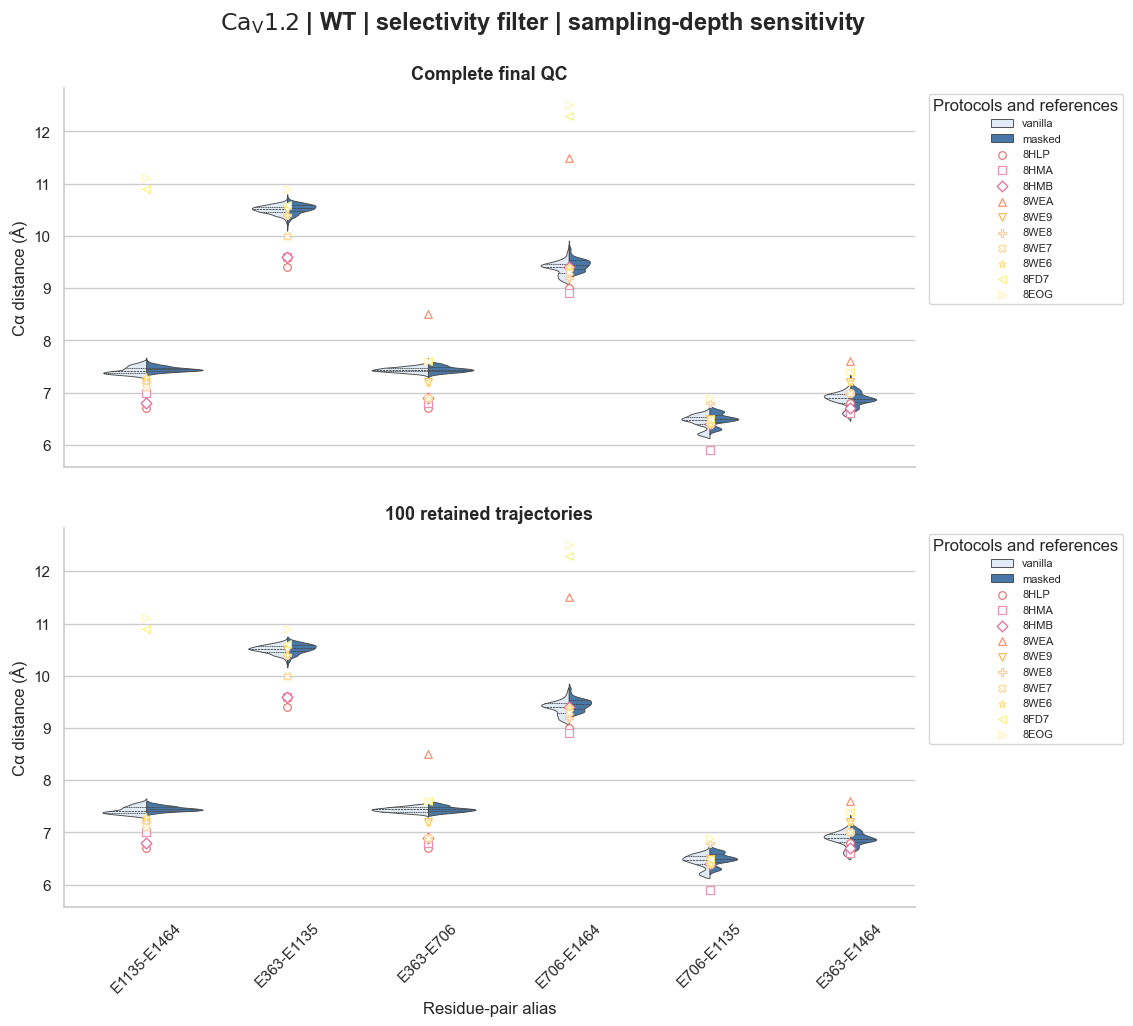

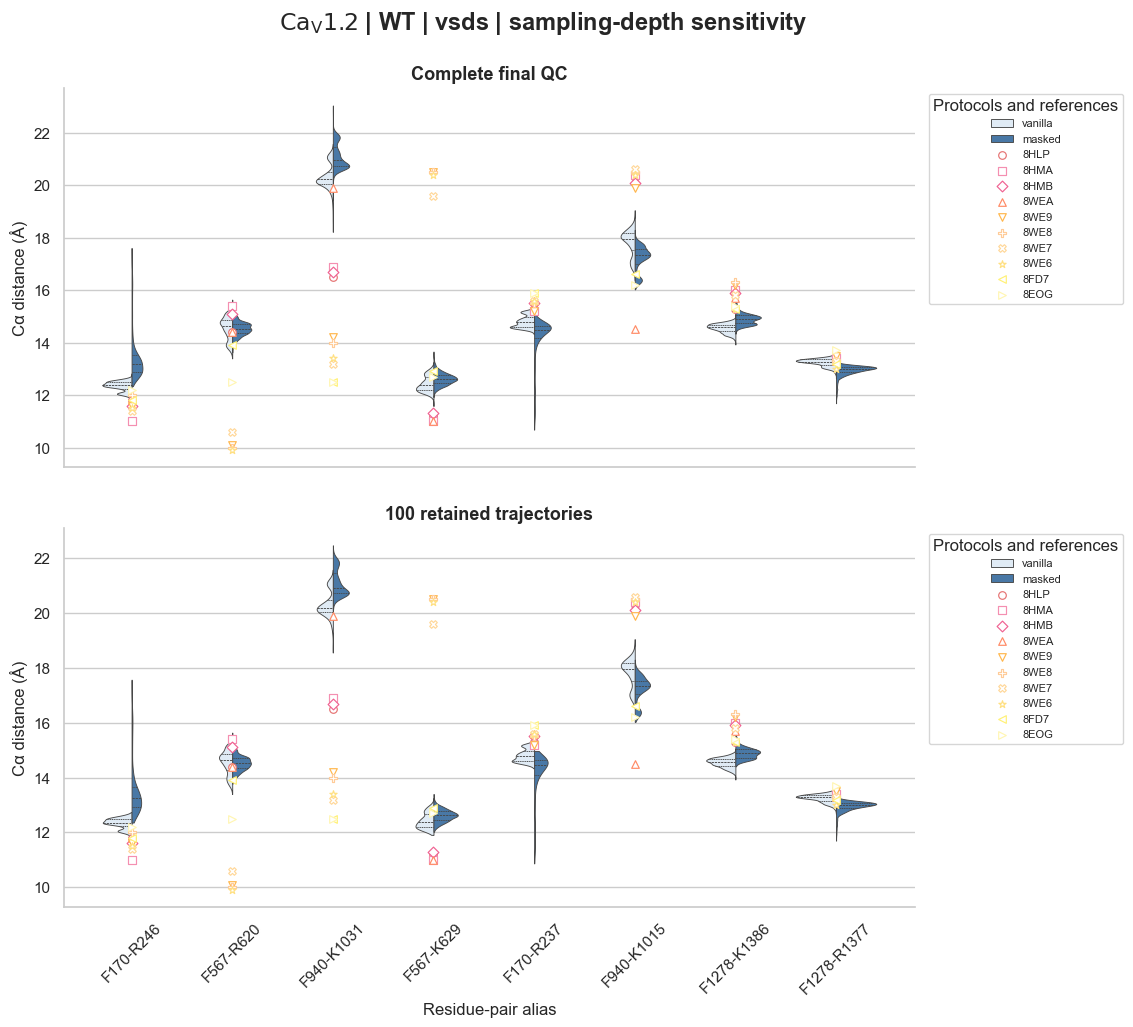

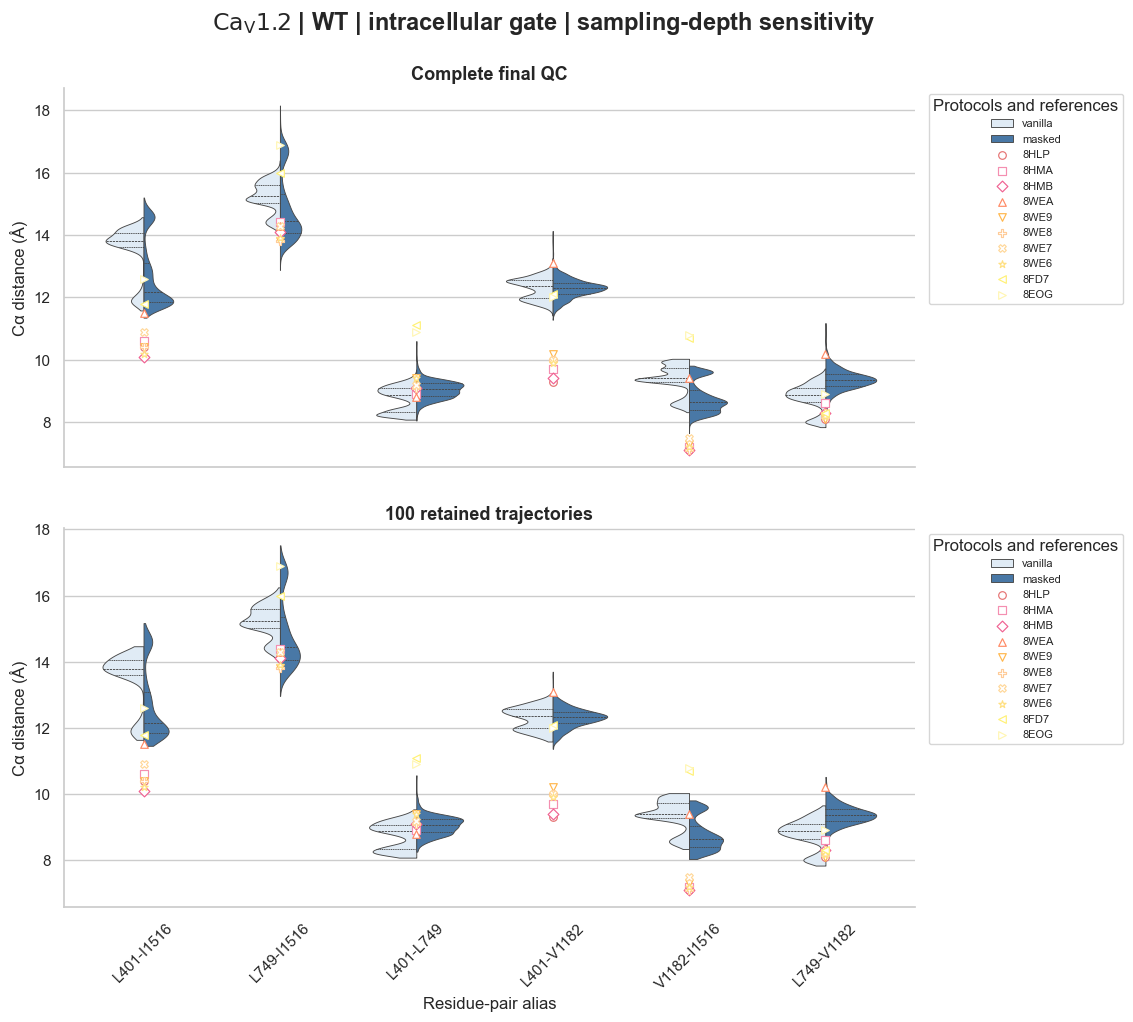

Loading CaV1.2 G402S


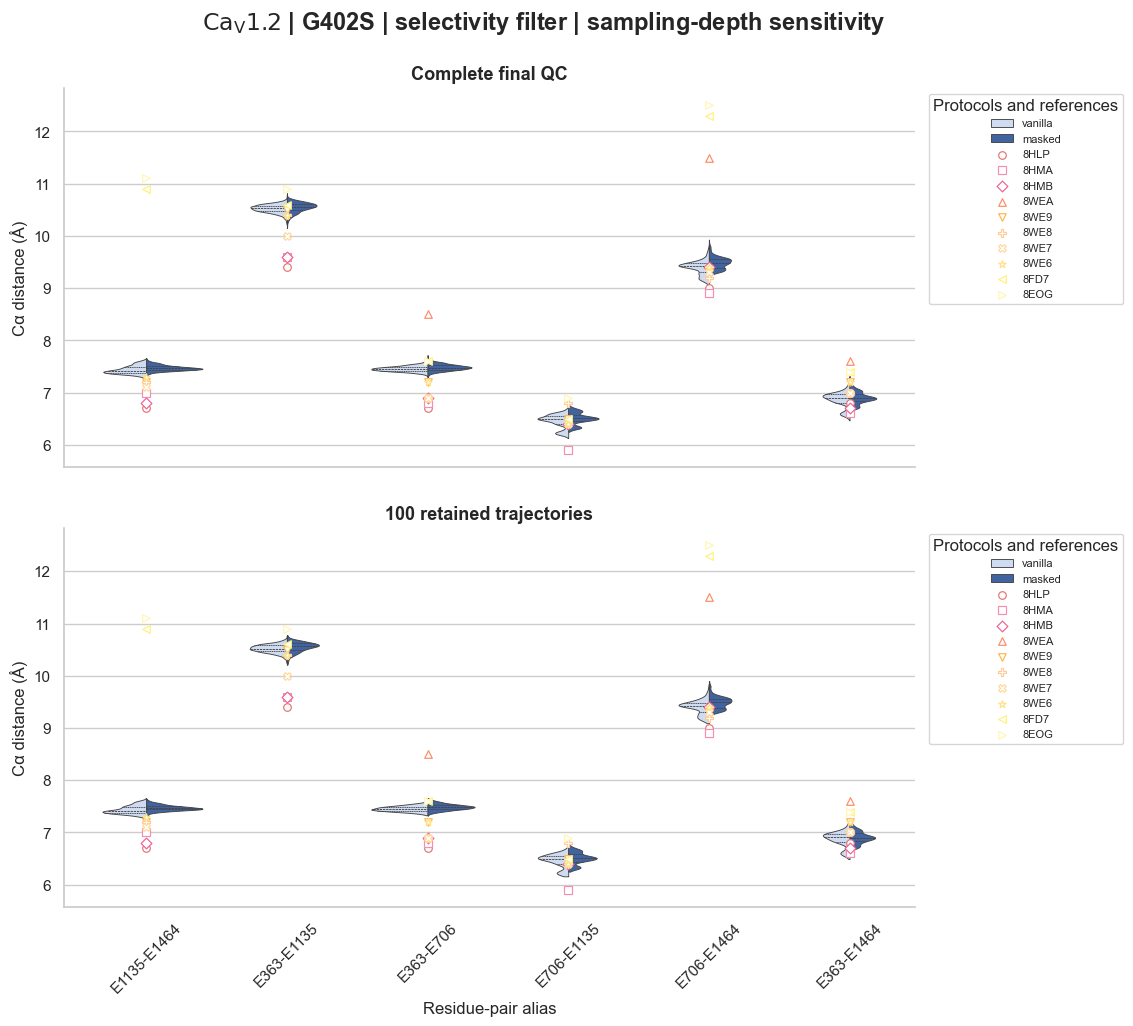

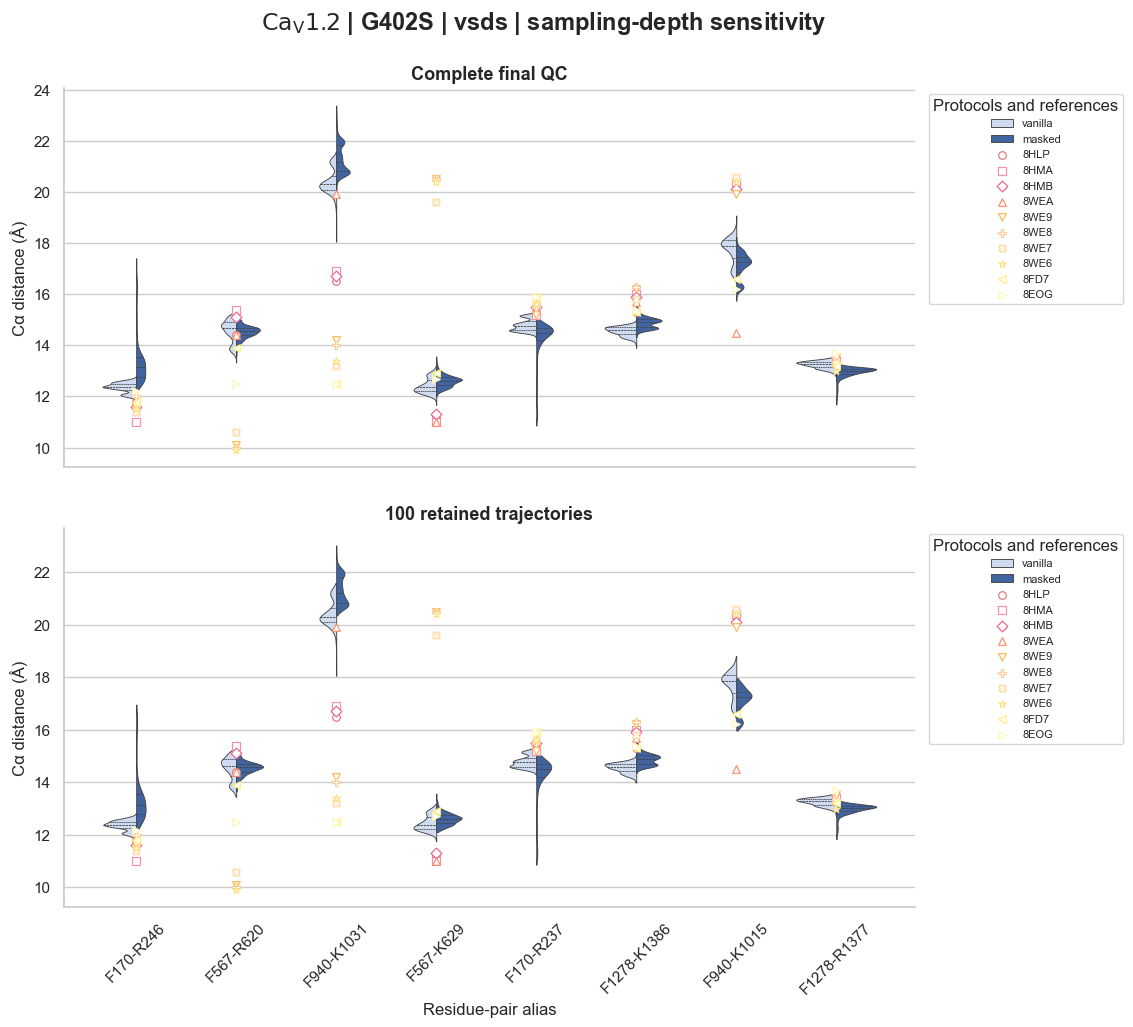

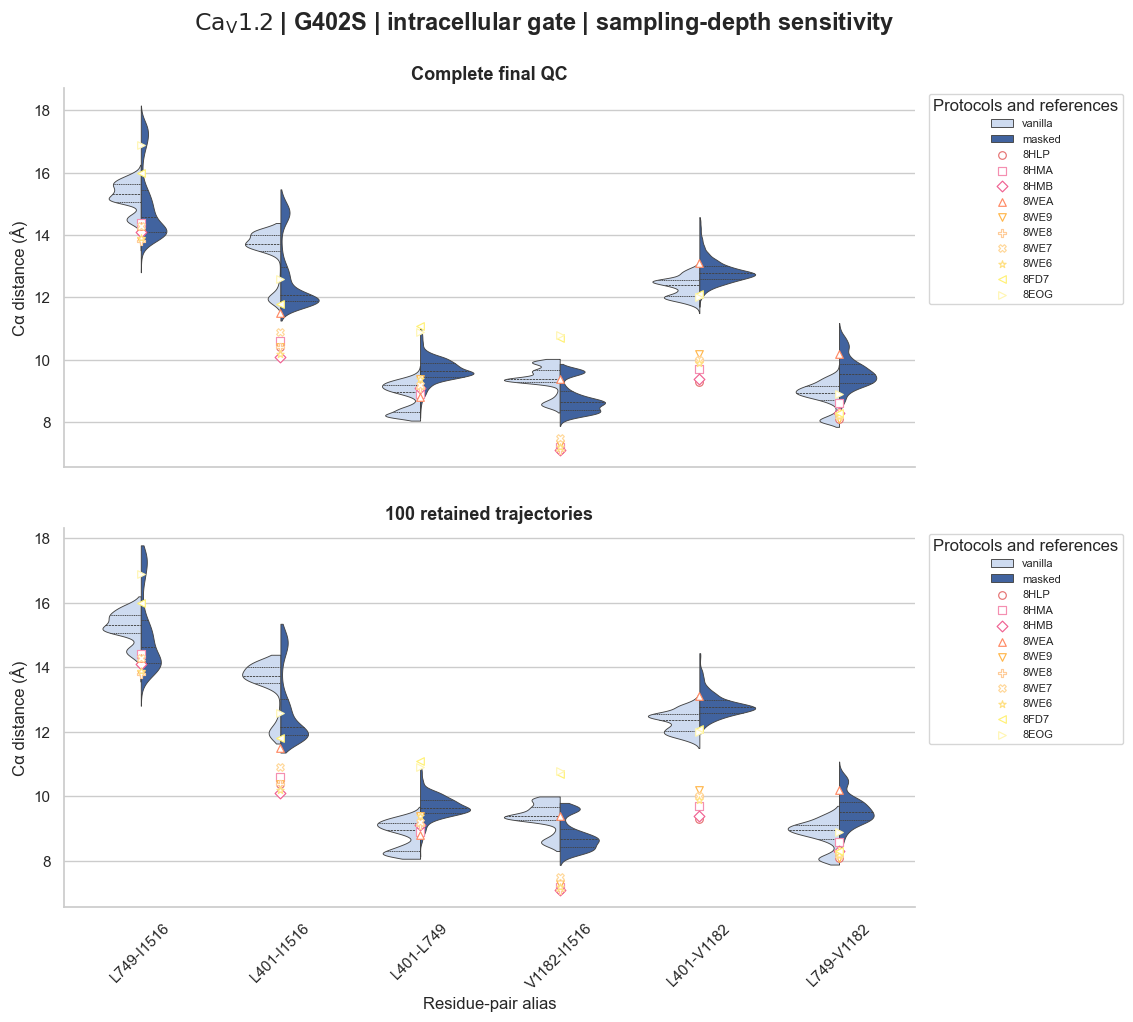

Loading CaV1.2 G406R


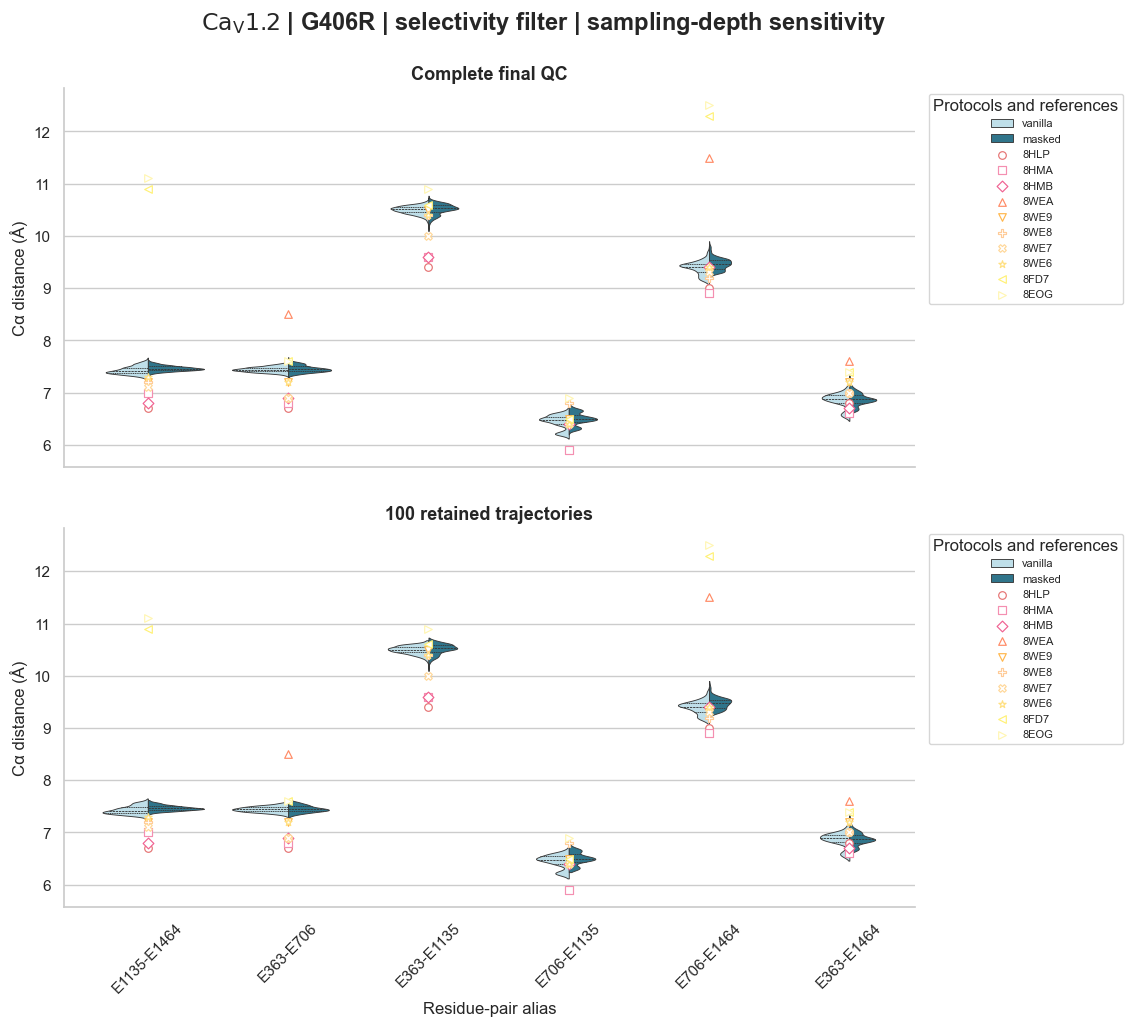

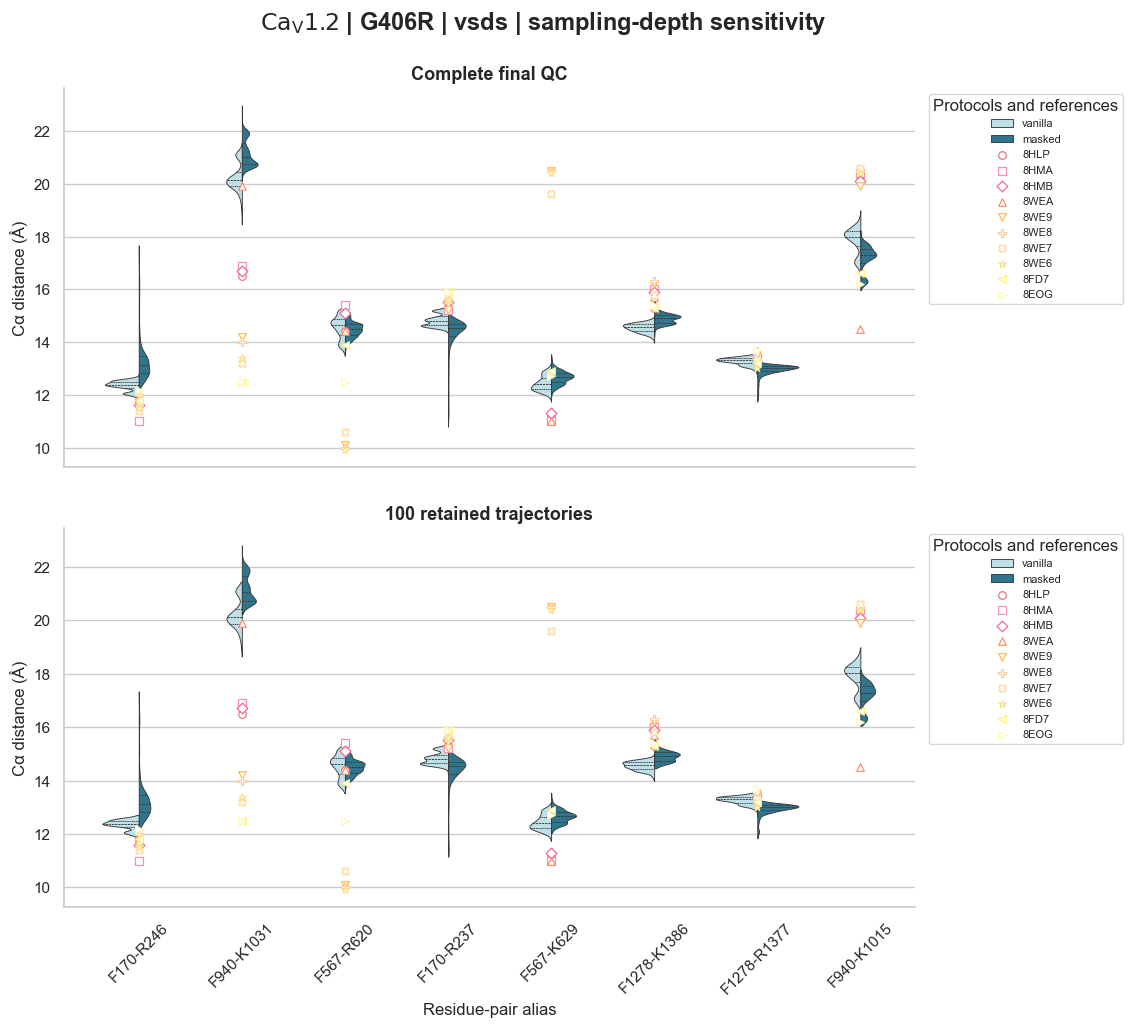

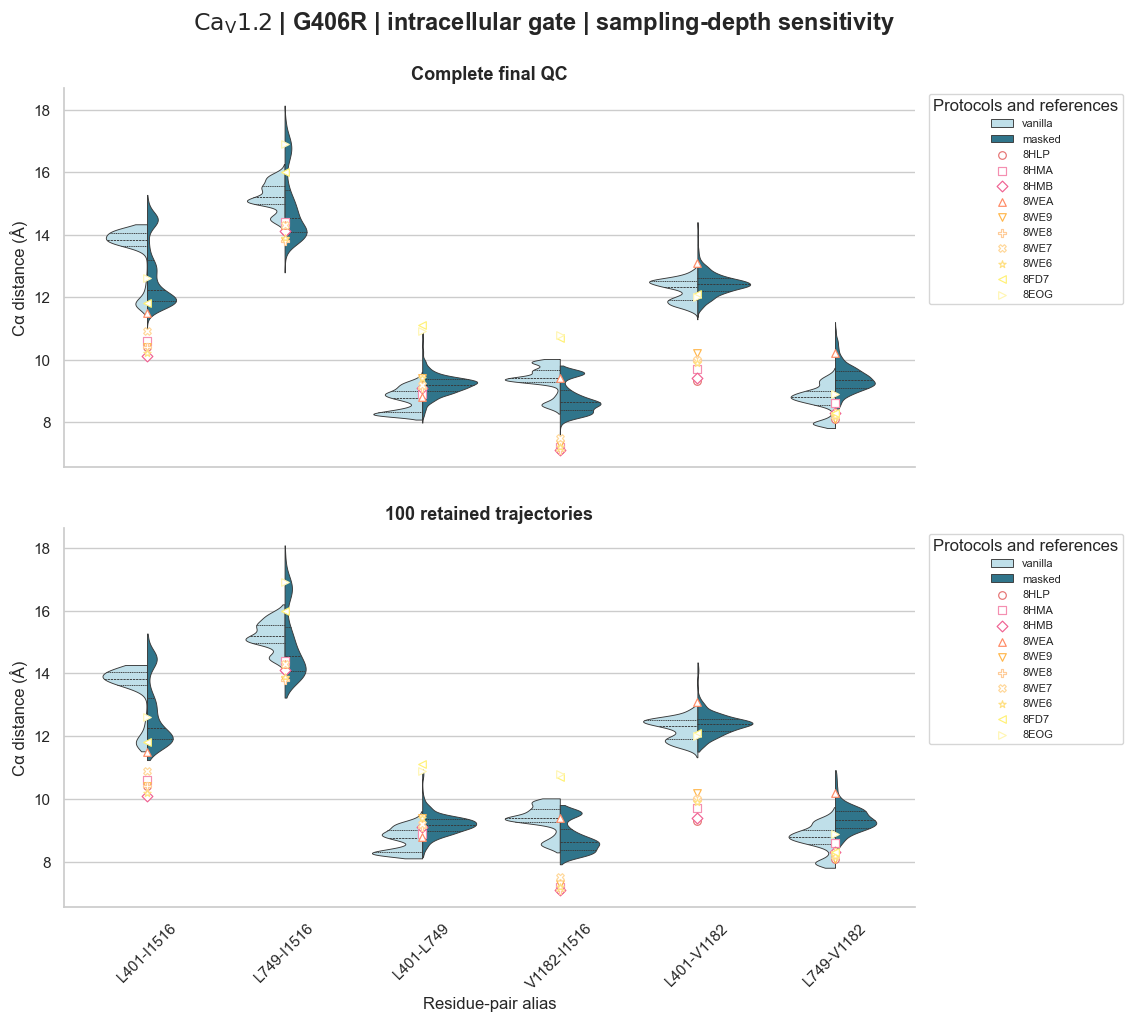

Loading Kv2.1 WT


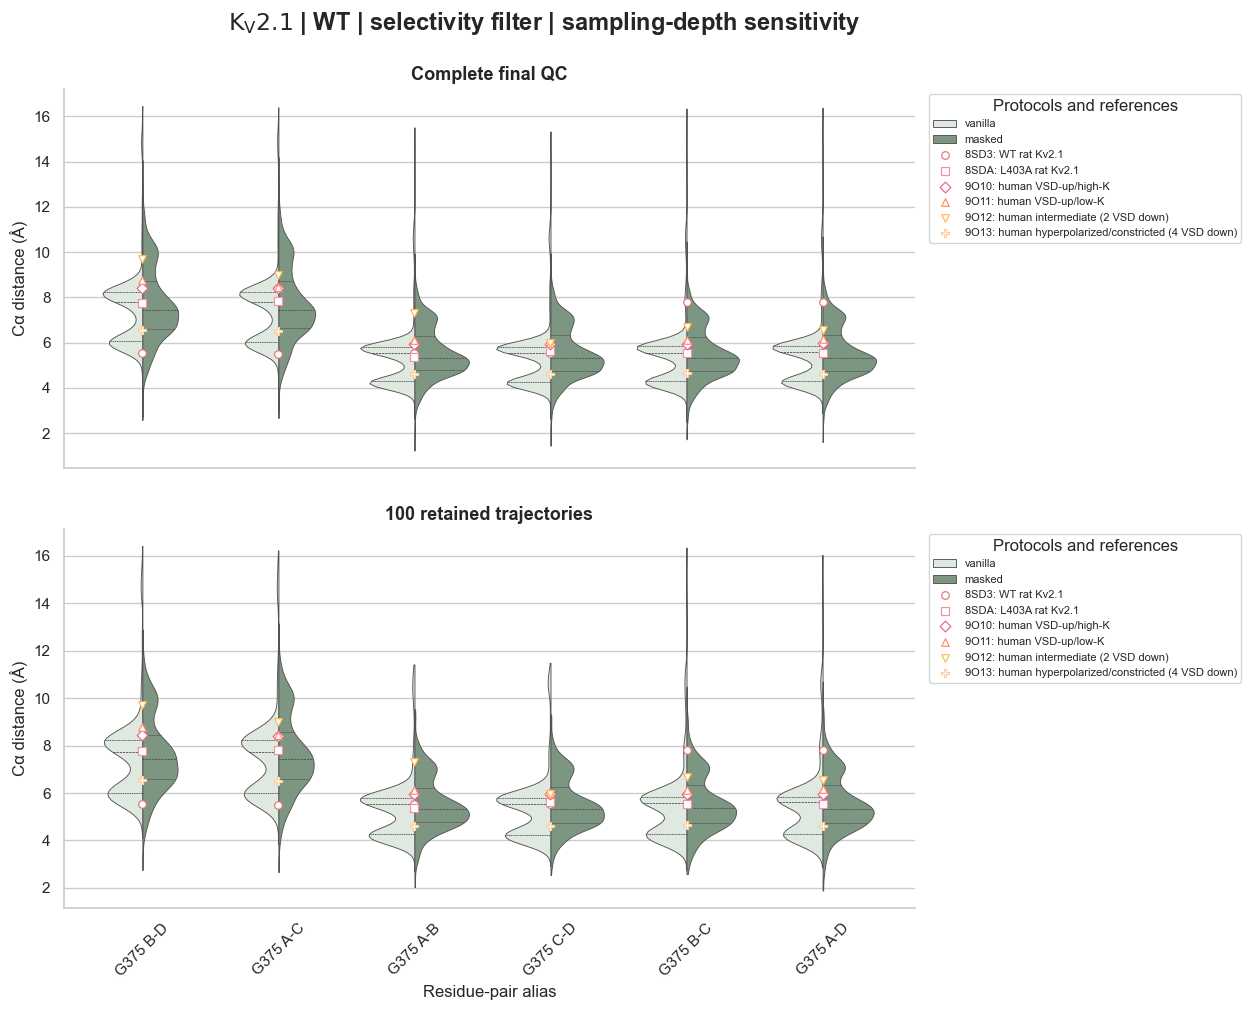

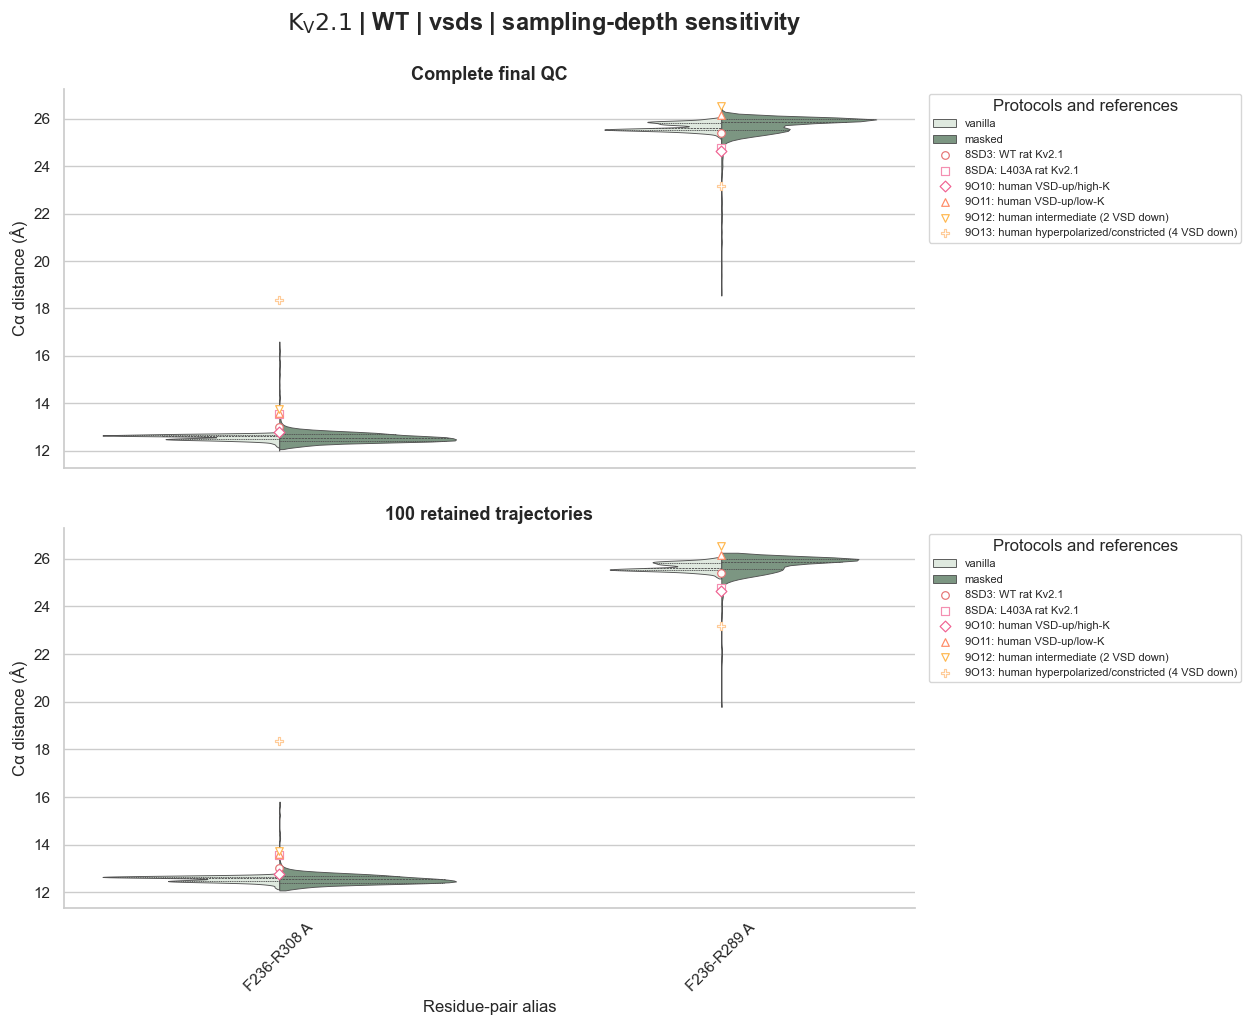

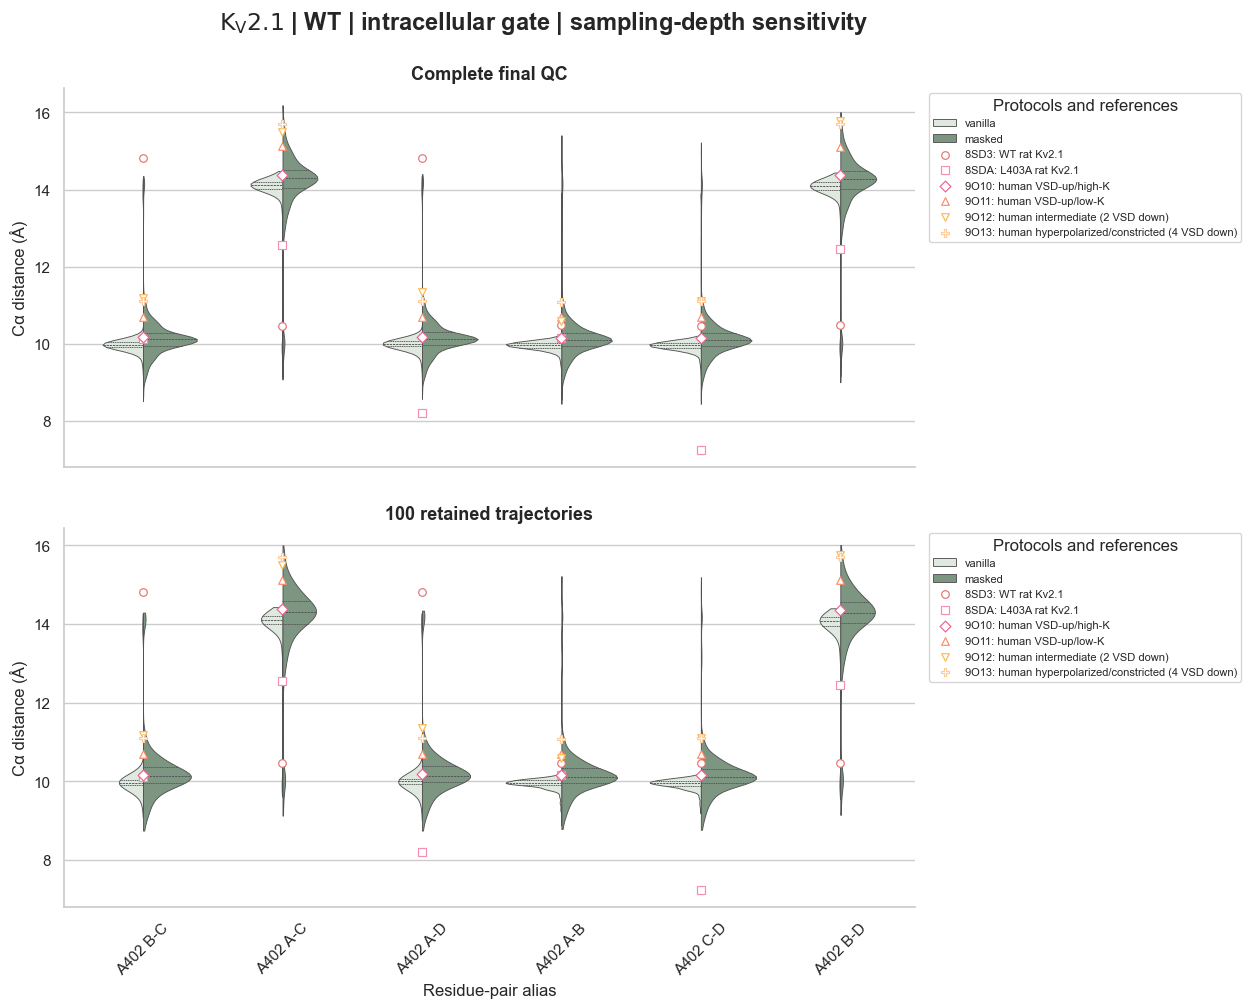

Loading Kv2.1 L403A


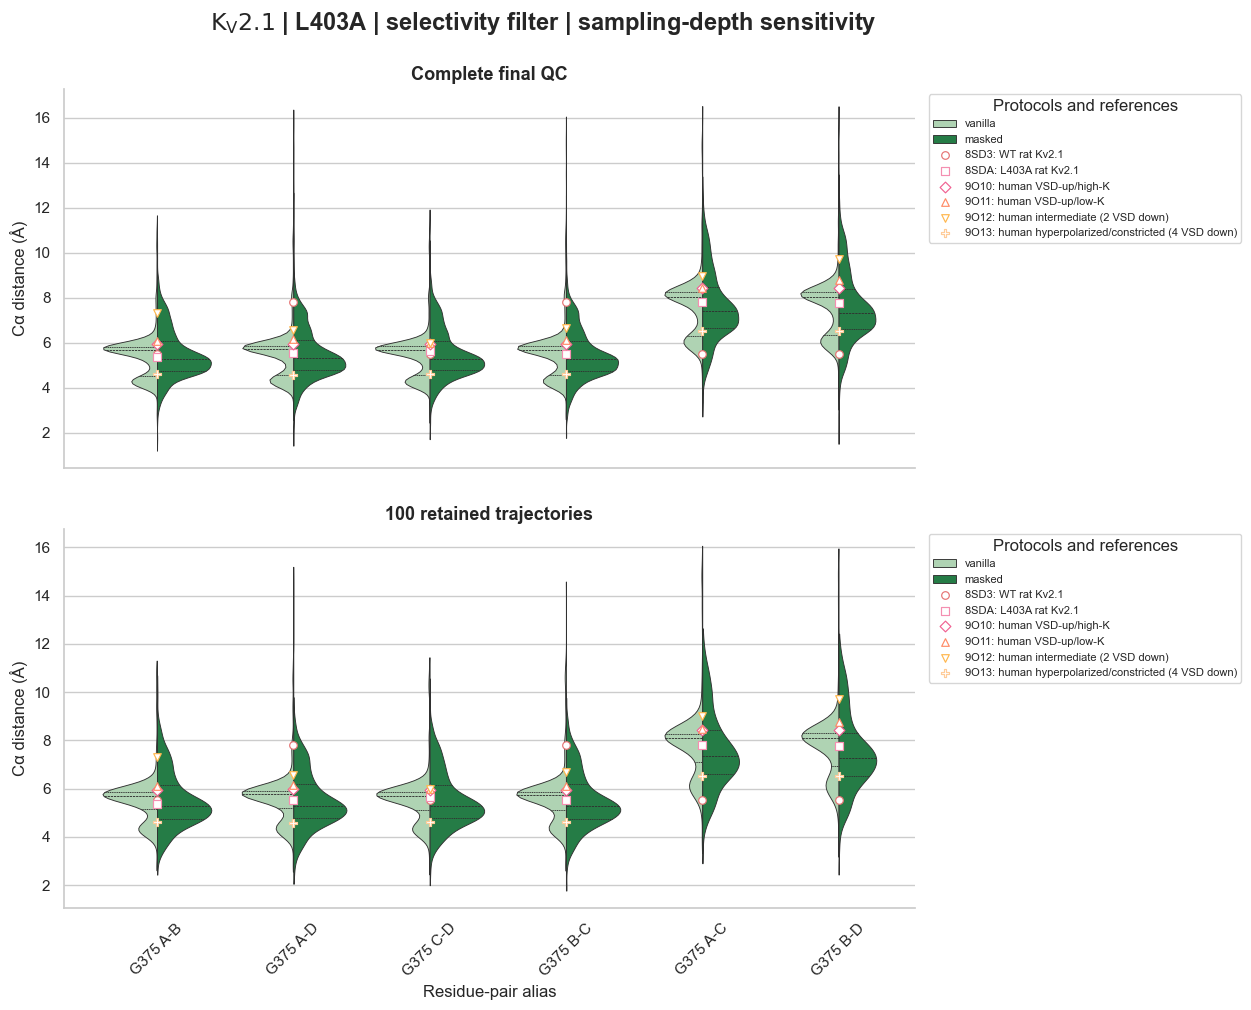

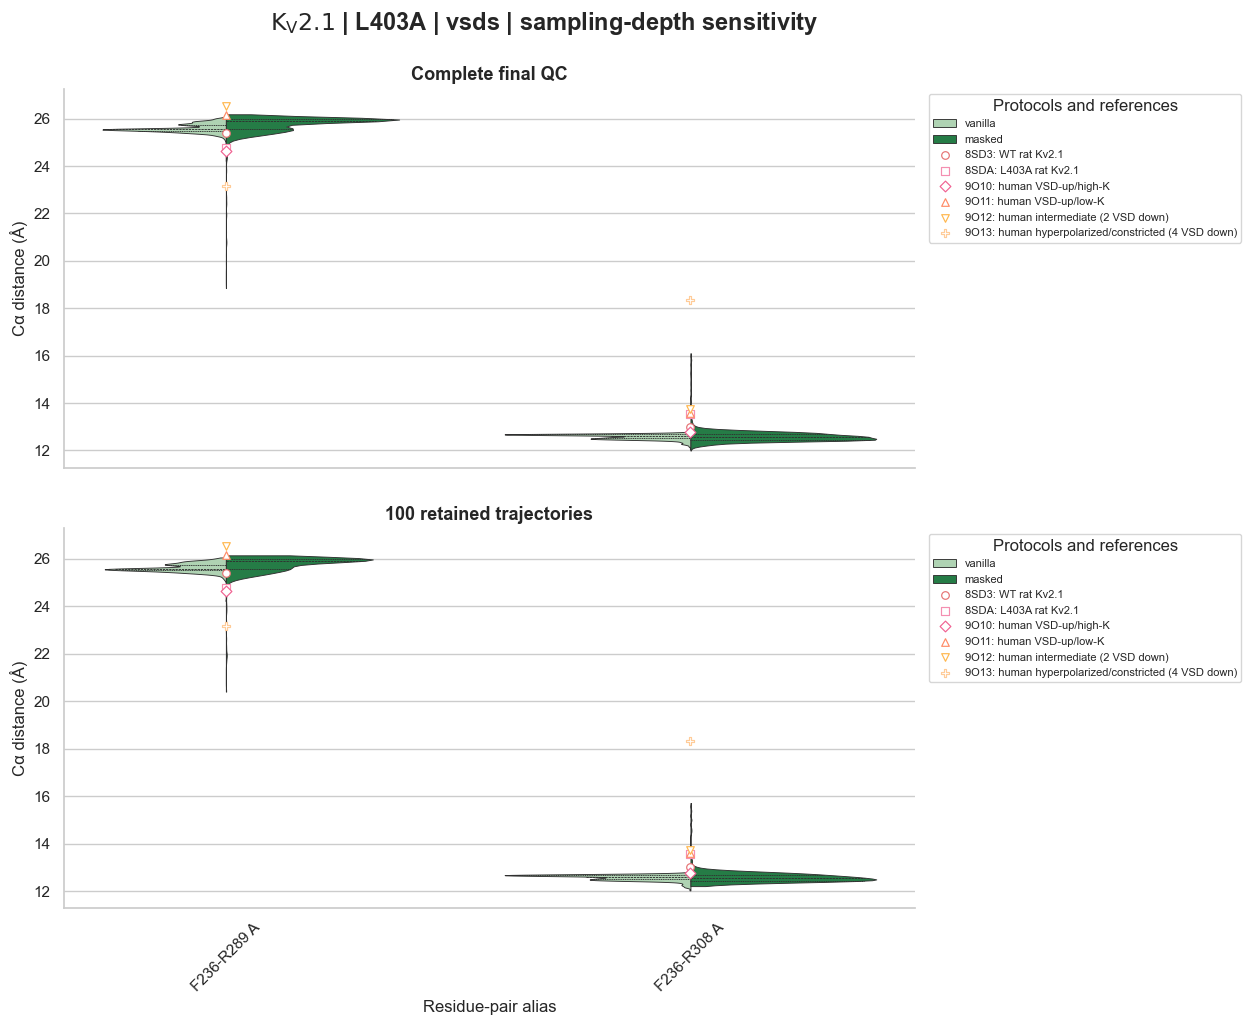

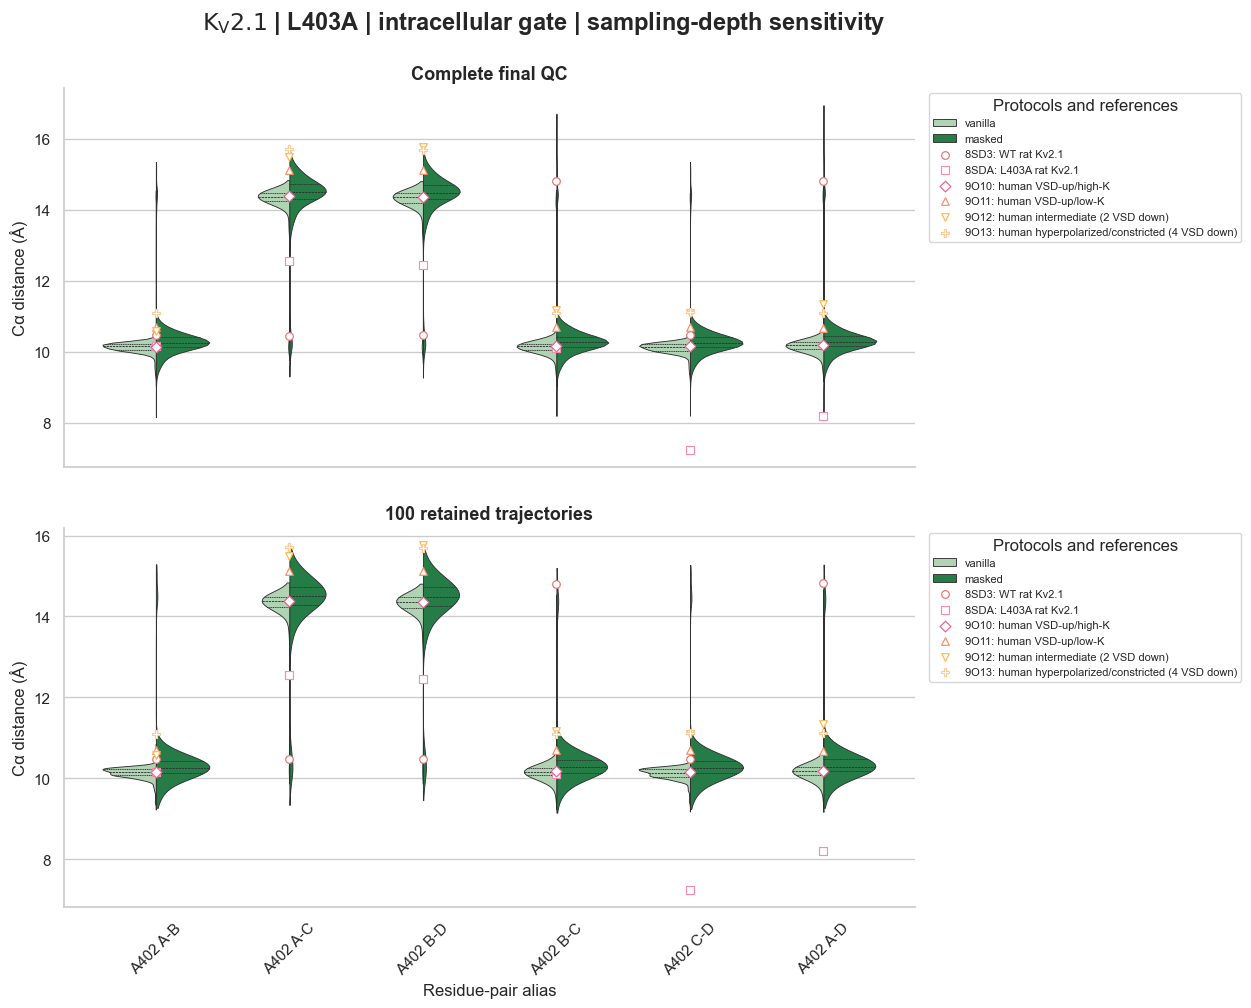

Loading Kv2.1 F412L


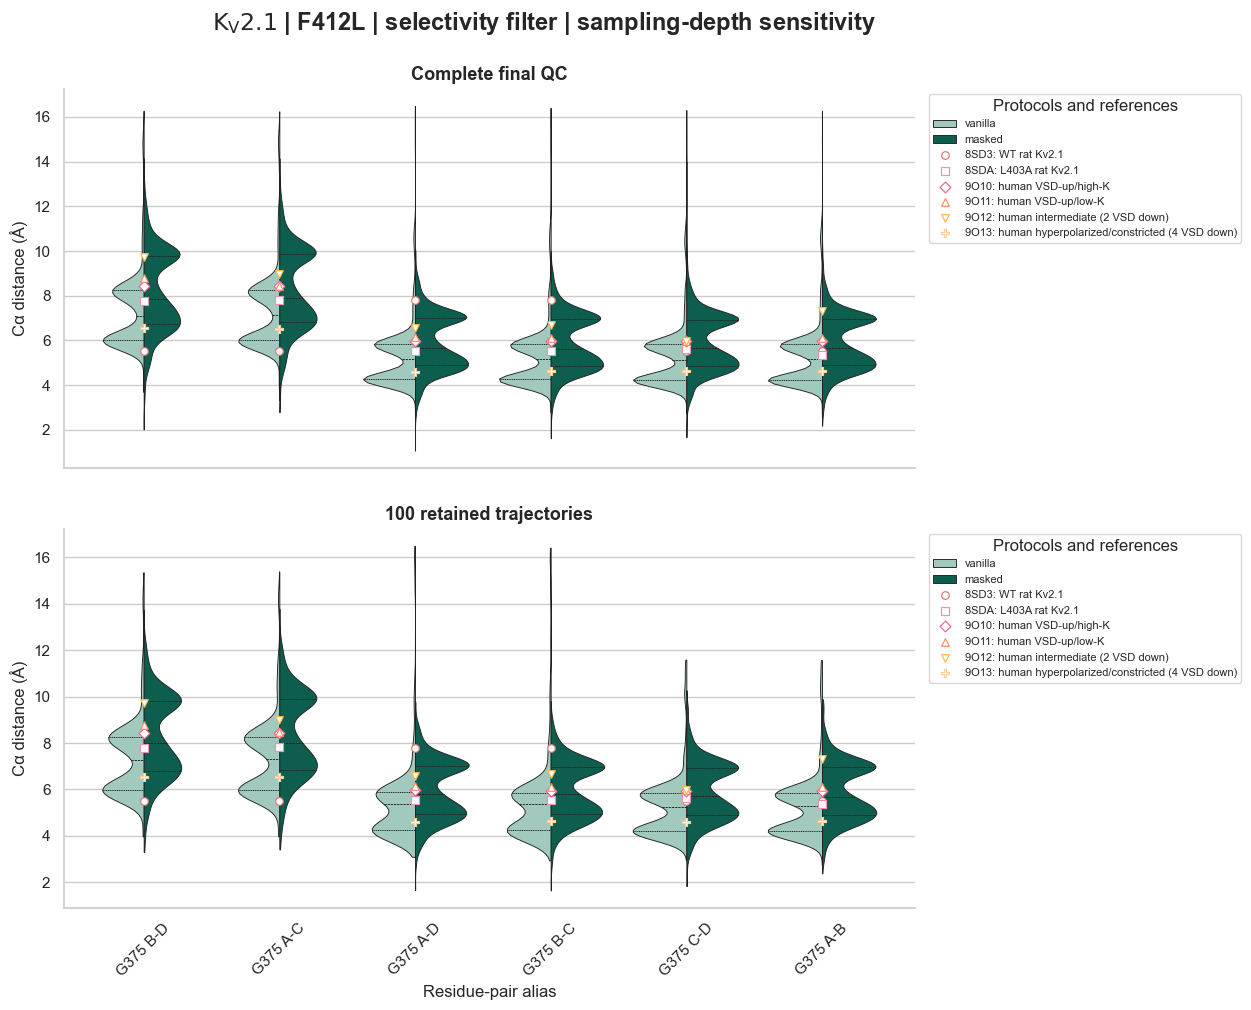

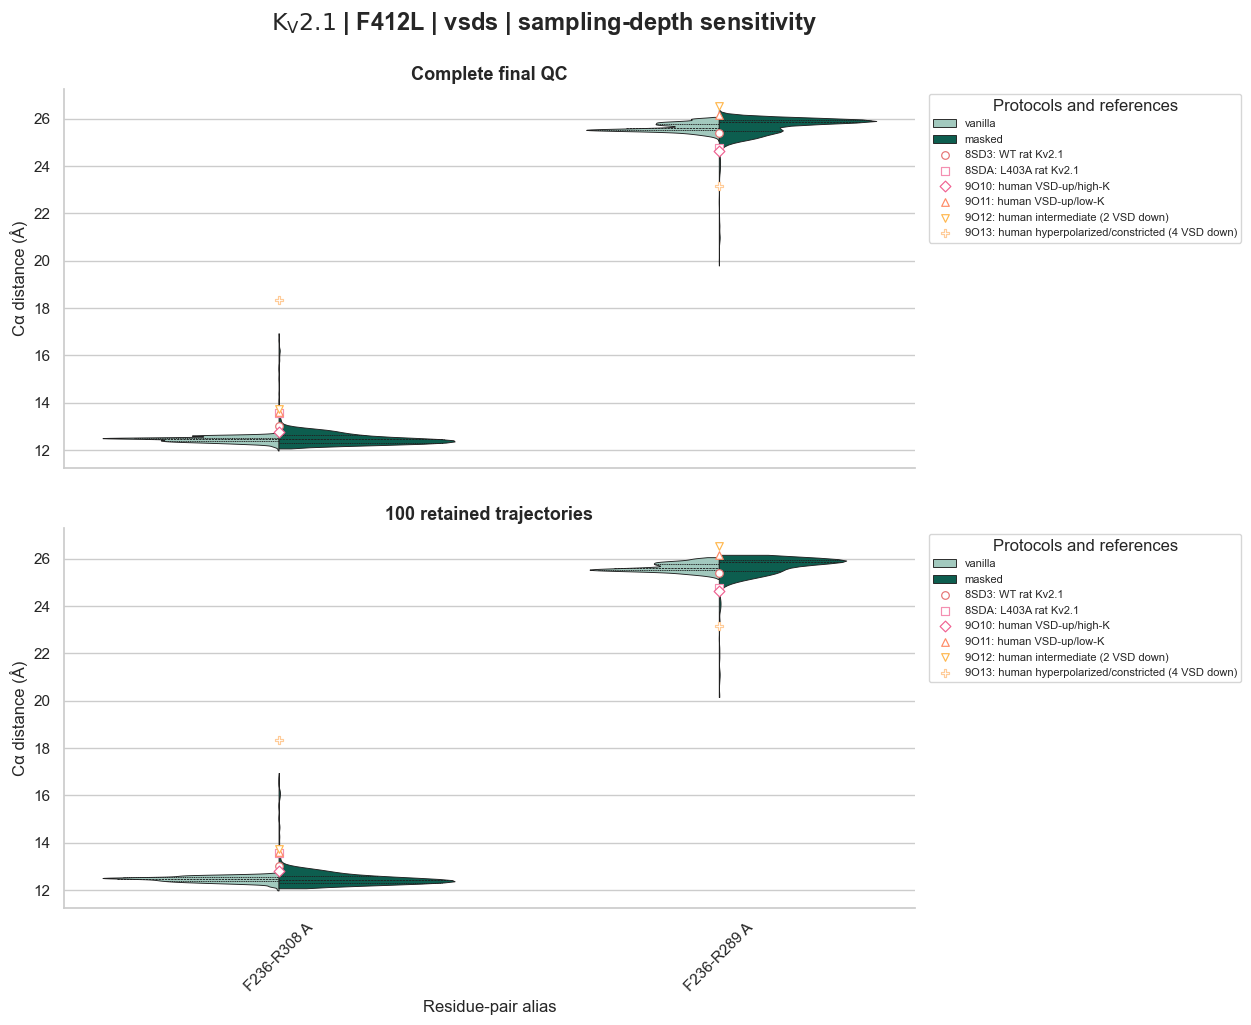

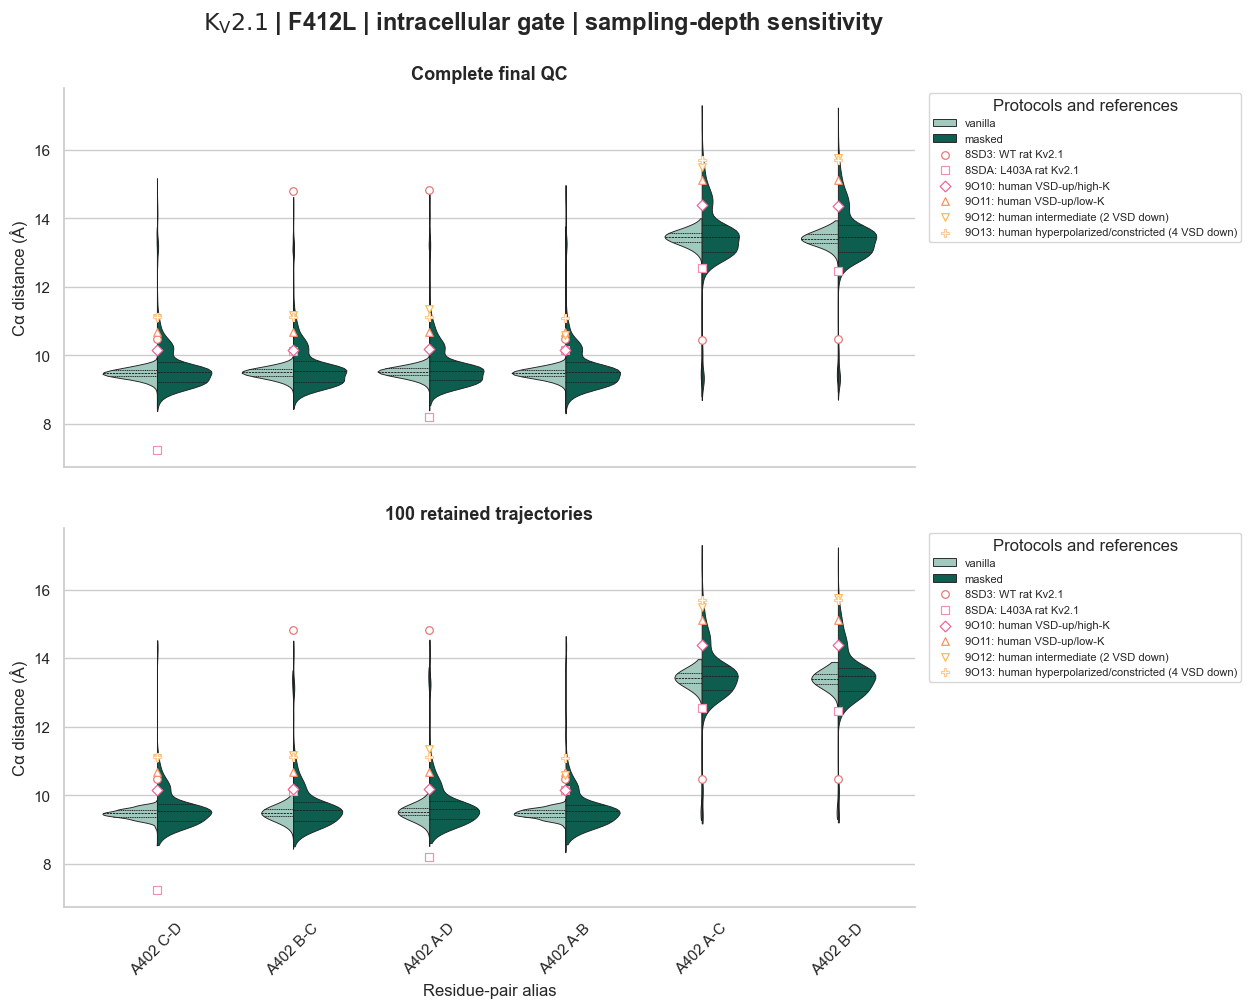

Loading NaV1.5 QQQ


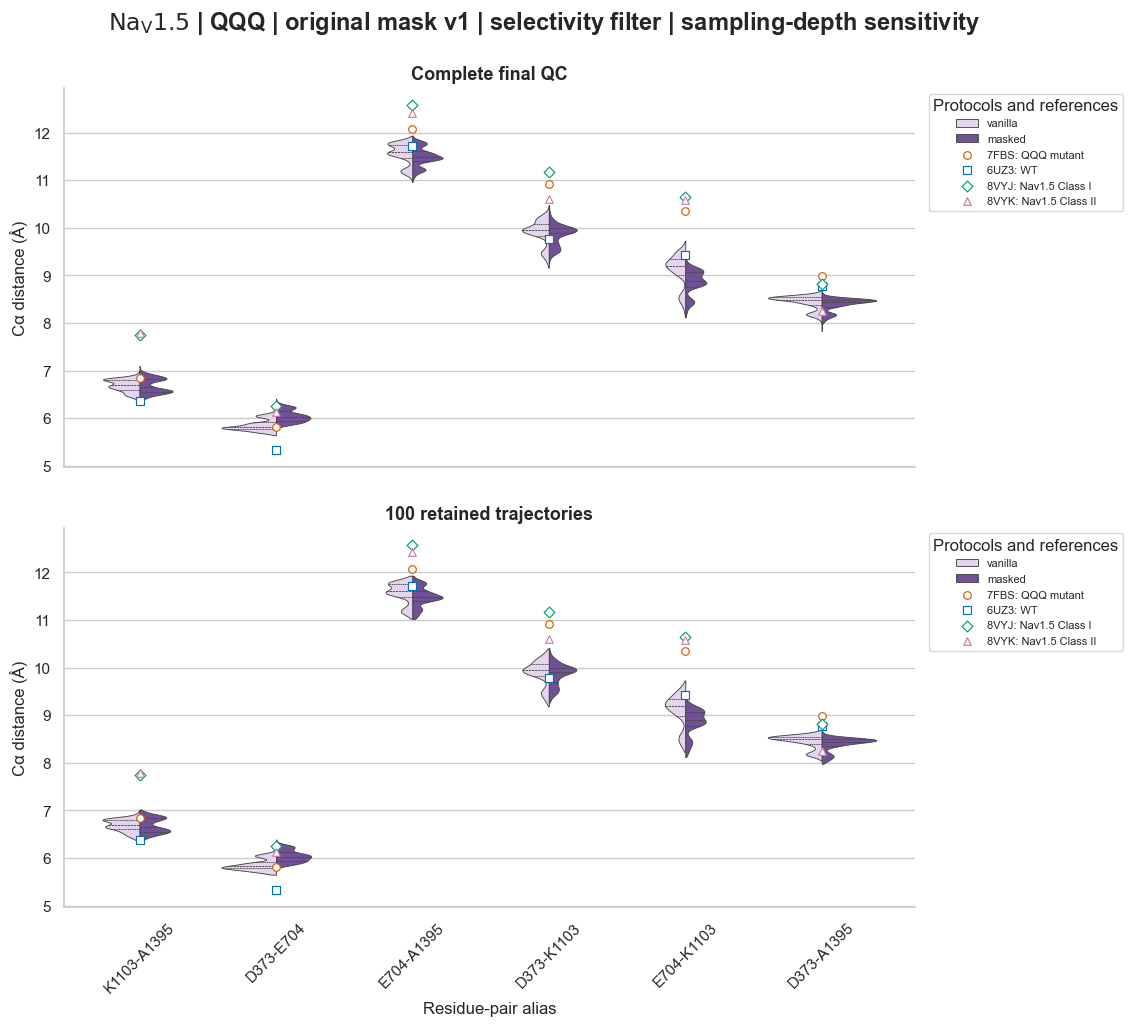

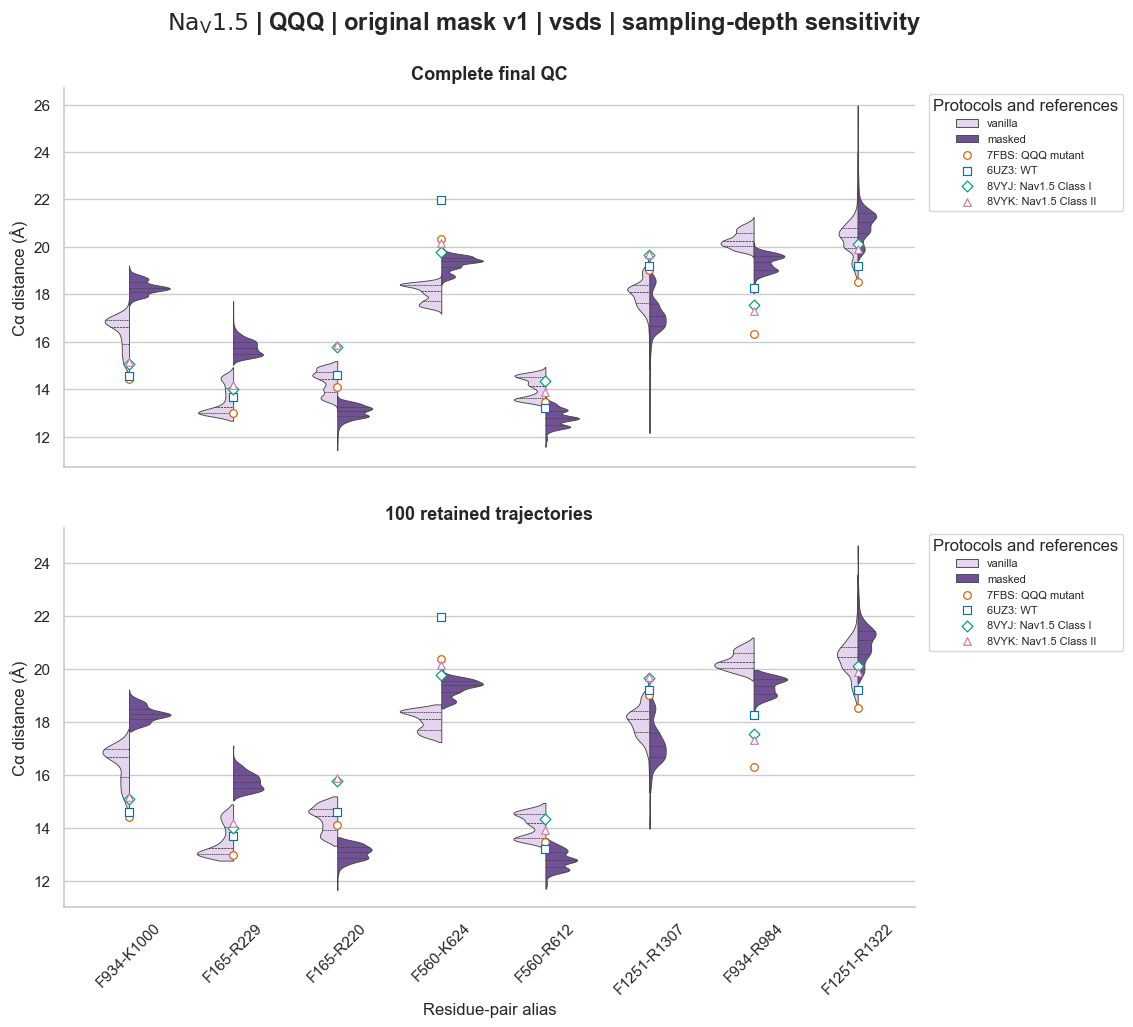

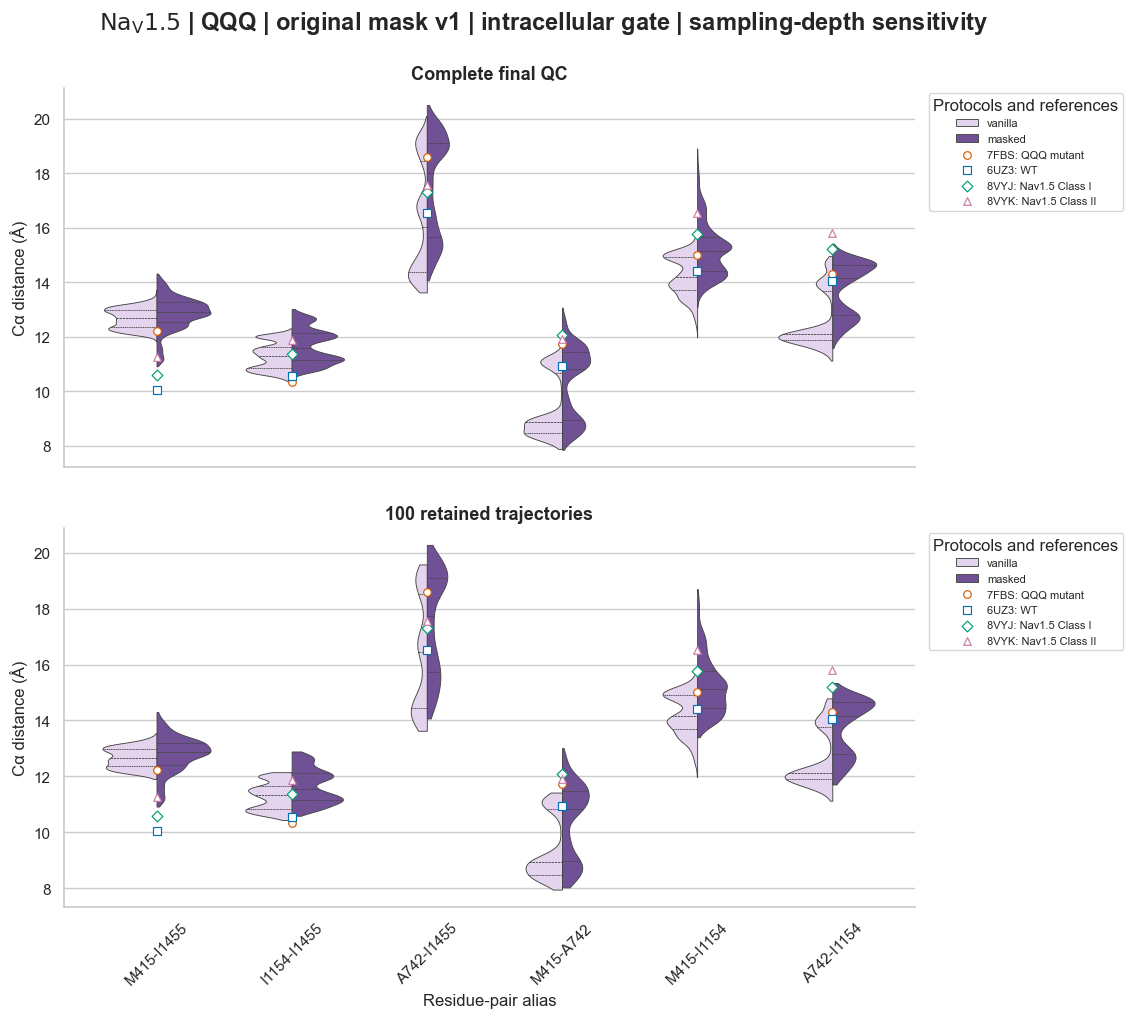

,Condition,Region,Subset,Shared distances,Median masked/vanilla IQR ratio,Fraction broader under masking,Vanilla rows,Masked rows
0,CaV1.2 WT,selectivity_filter,Complete final QC,6,0.941,0.333,5000,4996
1,CaV1.2 WT,selectivity_filter,100 retained trajectories,6,0.967,0.167,1000,1000
2,CaV1.2 WT,vsds,Complete final QC,8,1.126,0.625,5000,4996
3,CaV1.2 WT,vsds,100 retained trajectories,8,1.100,0.500,1000,1000
4,CaV1.2 WT,intracellular_gate,Complete final QC,6,1.135,0.500,5000,4996
5,CaV1.2 WT,intracellular_gate,100 retained trajectories,6,1.132,0.500,1000,1000
6,CaV1.2 G402S,selectivity_filter,Complete final QC,6,0.941,0.333,5000,4995
7,CaV1.2 G402S,selectivity_filter,100 retained trajectories,6,0.969,0.333,1000,999
8,CaV1.2 G402S,vsds,Complete final QC,8,1.106,0.500,5000,4995
9,CaV1.2 G402S,vsds,100 retained trajectories,8,1.091,0.500,1000,999


In [4]:
summary_rows = []
ranking_tables = {}
figure_dir = repo_root / 'docs' / 'figures' / 'sampling_depth'
table_dir = repo_root / 'docs' / 'tables' / 'sampling_depth'
figure_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)

for name, config in DATASETS.items():
    print(f'Loading {name}')
    frames = load_final_qc_pair({'vanilla': config['vanilla'], 'masked': config['masked']})
    for region, aliases in REGIONS[config['channel']].items():
        ranking, figure = plot_sampling_depth_condition(
            repo_root, config['condition'], config['channel'], region,
            frames, aliases, config['colors'], top_n=8,
        )
        if figure is None:
            print(f'No complete shared columns: {name} | {region}')
            continue
        display(figure)
        safe_name = name.lower().replace(' ', '_').replace('.', '')
        safe_region = region.replace(' ', '_')
        figure.savefig(figure_dir / f'{safe_name}_{safe_region}.png', dpi=400, bbox_inches='tight')
        ranking.to_csv(table_dir / f'{safe_name}_{safe_region}_ranking.csv', index=False)
        ranking_tables[(name, region)] = ranking
        summary_rows.extend(summarize_sampling_depth(name, region, frames, ranking))
        plt.close(figure)

sampling_summary = pd.DataFrame(summary_rows)
sampling_summary.to_csv(table_dir / 'sampling_depth_summary.csv', index=False)
display(sampling_summary.round(3))


## Cross-condition sensitivity summary

Values close between the two bars indicate that the qualitative masking effect is already visible with 100 retained trajectories. Large disagreements identify conclusions that depend on deeper sampling and should not be inferred from a small ensemble.


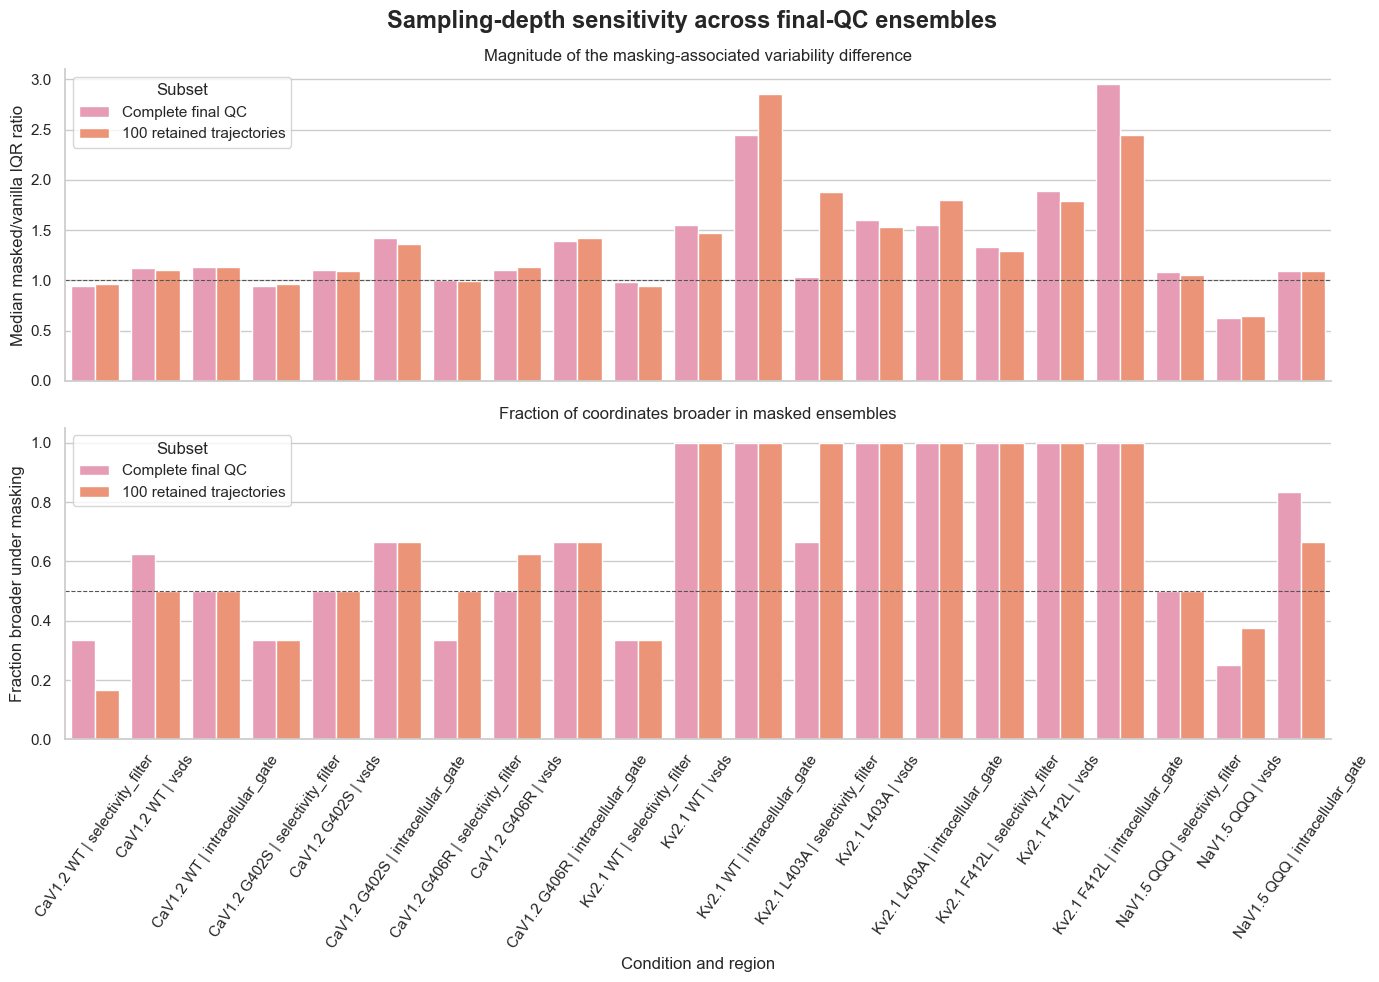

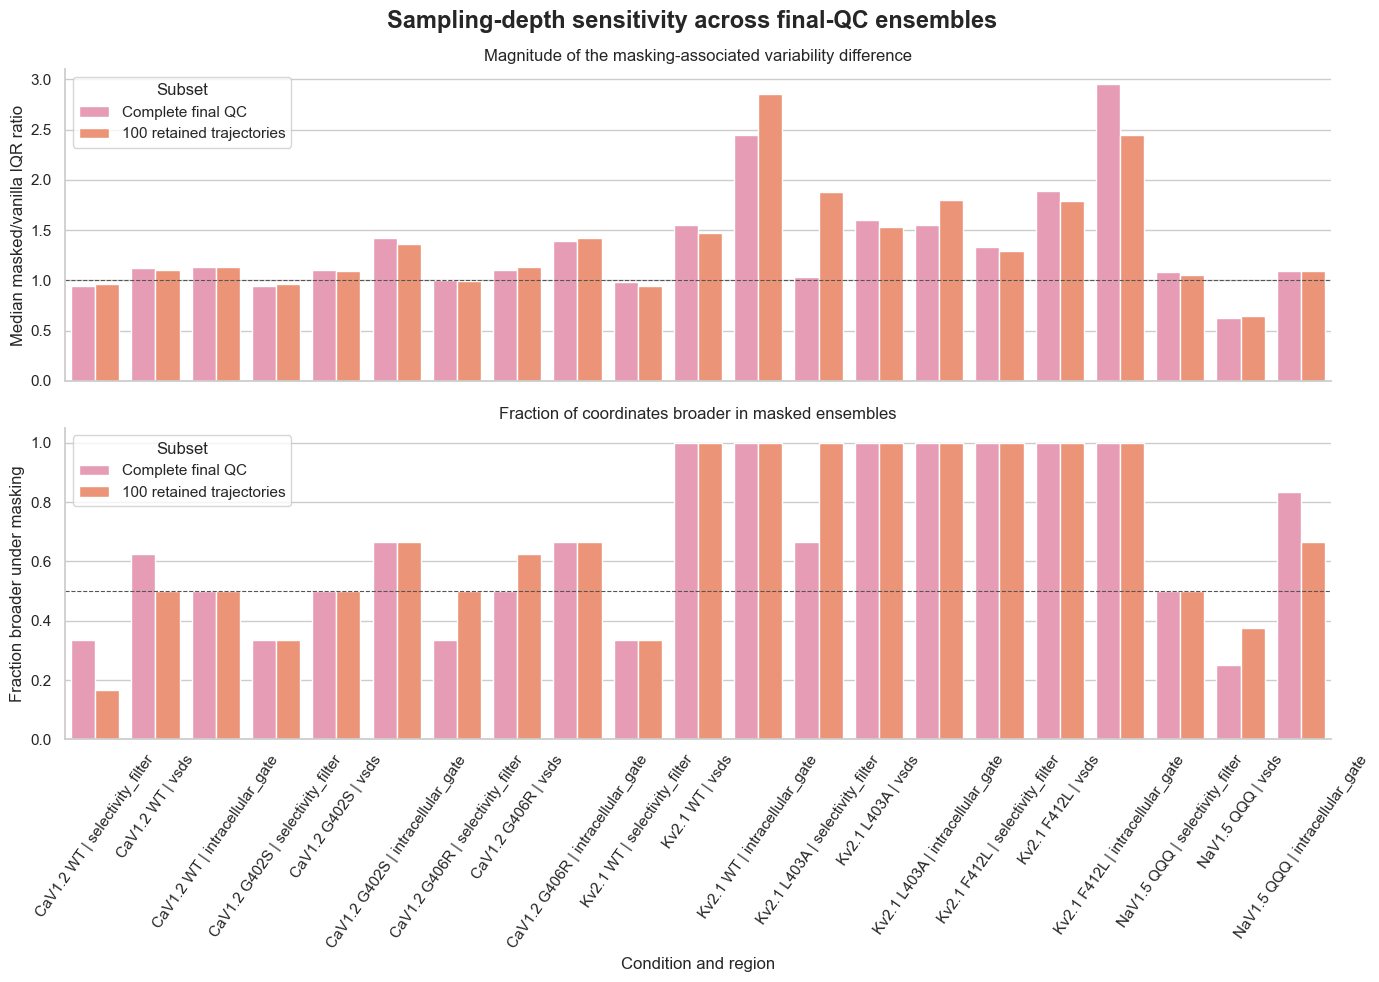

In [5]:
plot_data = sampling_summary.copy()
plot_data['Condition and region'] = plot_data['Condition'] + ' | ' + plot_data['Region']
subset_palette = {'Complete final QC': ACCENT_PALETTE['PINK'], '100 retained trajectories': ACCENT_PALETTE['CORAL']}
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
sns.barplot(data=plot_data, x='Condition and region', y='Median masked/vanilla IQR ratio', hue='Subset', palette=subset_palette, ax=axes[0])
axes[0].axhline(1, color='#555555', linewidth=0.8, linestyle='--')
axes[0].set_title('Magnitude of the masking-associated variability difference')
sns.barplot(data=plot_data, x='Condition and region', y='Fraction broader under masking', hue='Subset', palette=subset_palette, ax=axes[1])
axes[1].axhline(0.5, color='#555555', linewidth=0.8, linestyle='--')
axes[1].set_title('Fraction of coordinates broader in masked ensembles')
axes[1].tick_params(axis='x', rotation=55)
for axis in axes:
    axis.grid(axis='x', visible=False)
    sns.despine(ax=axis)
fig.suptitle('Sampling-depth sensitivity across final-QC ensembles', fontsize=17, fontweight='semibold')
fig.tight_layout()
display(fig)
fig.savefig(figure_dir / 'sampling_depth_cross_condition_summary.png', dpi=400, bbox_inches='tight')
